In [2]:
#REGRESIÓN LINEAL SIMPLE
#Encontrar relacion entre una o mas variables para buscar una predicción

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os 
os.chdir("/Users/SURFACE")

In [5]:
df = pd.read_excel("FuelConsumptionCo2.xlsx")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2022,Acura,ILX,Compact,2.4,4,AM8,Z,9.9,7.0,8.6,33,200
1,2022,Acura,MDX SH-AWD,SUV: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263
2,2022,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,Z,11.0,8.6,9.9,29,232
3,2022,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,Z,11.3,9.1,10.3,27,242
4,2022,Acura,TLX SH-AWD,Compact,2.0,4,AS10,Z,11.2,8.0,9.8,29,230


In [6]:
#Exploración de datos
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,945.0,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000,945.000000
mean,2022.0,3.201058,5.670899,12.515767,9.374603,11.102222,27.222222,259.410582
std,0.0,1.374256,1.932837,3.452369,2.290217,2.878074,7.684409,64.486225
min,2022.0,1.200000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000
25%,2022.0,2.000000,4.000000,10.200000,7.700000,9.100000,22.000000,214.000000
50%,2022.0,3.000000,6.000000,12.200000,9.200000,10.800000,26.000000,258.000000
75%,2022.0,3.800000,6.000000,14.700000,10.700000,12.900000,31.000000,301.000000
max,2022.0,8.000000,16.000000,30.300000,20.900000,26.100000,71.000000,608.000000


In [7]:
cdf = df[['ENGINESIZE','CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,8.6,200
1,3.5,6,11.2,263
2,2.0,4,9.9,232
3,2.0,4,10.3,242
4,2.0,4,9.8,230
5,2.0,4,9.8,231
6,3.0,6,11.0,256
7,3.0,6,11.2,261
8,2.0,4,8.7,205


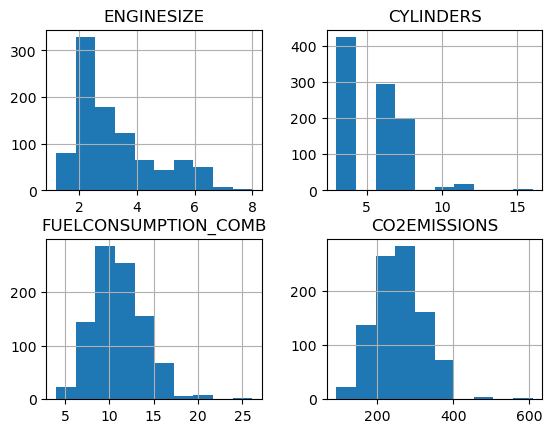

In [8]:
viz = cdf[['ENGINESIZE','CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist()
plt.show()

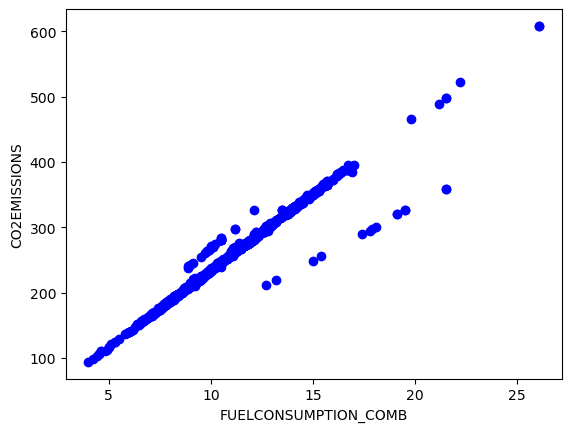

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.show()

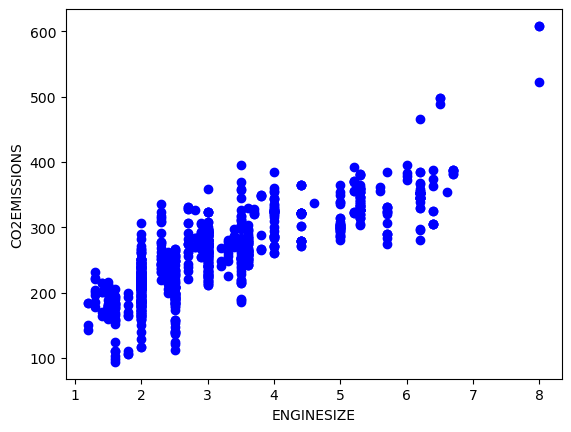

In [10]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

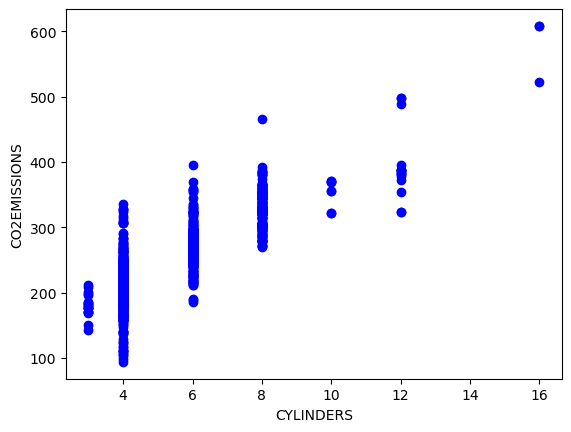

In [11]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('CYLINDERS')
plt.ylabel('CO2EMISSIONS')
plt.show()

In [12]:
msk = np.random.rand(len(df)) <= 0.80
msk

array([ True,  True,  True,  True, False,  True, False,  True,  True,
        True,  True, False, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True, False,  True,  True, False,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,

In [13]:
train = cdf[msk]
train

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,8.6,200
1,3.5,6,11.2,263
2,2.0,4,9.9,232
3,2.0,4,10.3,242
5,2.0,4,9.8,231
...,...,...,...,...
940,2.0,4,9.4,219
941,2.0,4,9.4,219
942,2.0,4,9.9,232
943,2.0,4,10.1,236


In [14]:
test = cdf[~msk]
msk

array([ True,  True,  True,  True, False,  True, False,  True,  True,
        True,  True, False, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True, False,  True, False,  True,  True, False,
        True, False,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,

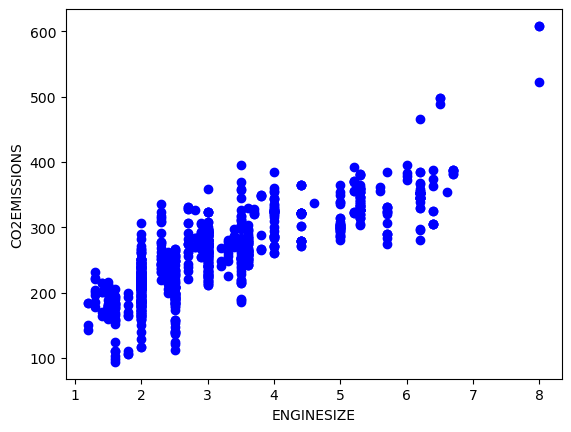

In [15]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.show()

In [17]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)

LinearRegression()

In [18]:
print('Coeficiente de pendiente', regr.coef_)
print('Coeficiente de intersección', regr.intercept_)

Coeficiente de pendiente [[39.76498735]]
Coeficiente de intersección [132.45310291]


CO2EMISSIONS = 132.45 + 39.76(ENGINESIZE)

Text(0, 0.5, 'Emissions')

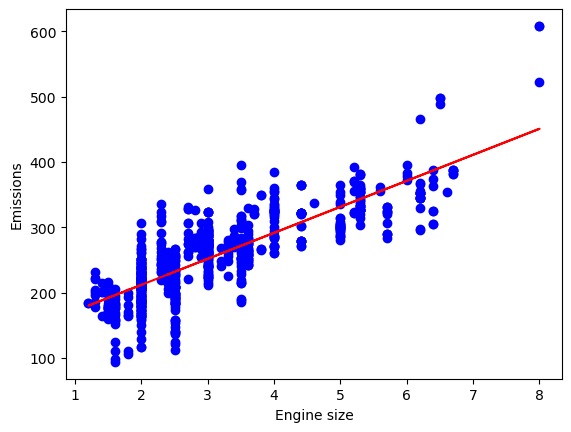

In [19]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color ='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emissions")

In [20]:
from sklearn.metrics import r2_score
test_x = np.asanyarray(train[['ENGINESIZE']])
test_y = np.asanyarray(train[['CO2EMISSIONS']])
test_y_hat = regr.predict(test_x)

In [21]:
test_y_hat

array([[227.88907256],
       [271.63055864],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [251.74806497],
       [211.98307761],
       [211.98307761],
       [247.77156623],
       [247.77156623],
       [291.51305232],
       [339.23103714],
       [291.51305232],
       [291.51305232],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [251.74806497],
       [251.74806497],
       [251.74806497],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [211.98307761],
       [251.74806497],
       [251.74806497],
       [339.23103714],
       [339.23103714],
       [339.23103714],
       [247.77156623],
       [247.77156623],
       [291.51305232],
       [291.51305232],
       [291.51305232],
       [211.98307761],
       [251.74806497],
       [251.74806497],
       [247

In [22]:
test_y

array([[200],
       [263],
       [232],
       [242],
       [231],
       [261],
       [205],
       [217],
       [271],
       [288],
       [271],
       [324],
       [343],
       [270],
       [178],
       [190],
       [205],
       [208],
       [214],
       [205],
       [205],
       [208],
       [224],
       [224],
       [248],
       [215],
       [217],
       [220],
       [220],
       [252],
       [273],
       [273],
       [322],
       [356],
       [322],
       [267],
       [268],
       [319],
       [315],
       [360],
       [206],
       [227],
       [227],
       [254],
       [254],
       [262],
       [262],
       [325],
       [218],
       [218],
       [209],
       [309],
       [383],
       [379],
       [294],
       [395],
       [323],
       [373],
       [195],
       [202],
       [202],
       [206],
       [219],
       [279],
       [279],
       [279],
       [279],
       [321],
       [212],
       [293],
       [296],
      

In [23]:
print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_hat - test_y)**2))
print("R2-score: %.2f" % r2_score(test_y_hat, test_y))

Mean absolute error: 28.87
Residual sum of squares (MSE): 1406.01
R2-score: 0.52


In [24]:
cdf = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.4,4,9.9,7.0,8.6,200
1,3.5,6,12.6,9.4,11.2,263
2,2.0,4,11.0,8.6,9.9,232
3,2.0,4,11.3,9.1,10.3,242
4,2.0,4,11.2,8.0,9.8,230
5,2.0,4,11.3,8.1,9.8,231
6,3.0,6,12.3,9.4,11.0,256
7,3.0,6,12.3,9.8,11.2,261
8,2.0,4,10.0,7.2,8.7,205


In [25]:
x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (x,y)
print('Coeficiente de pendiente', regr.coef_)
print('Coeficiente de intersección', regr.intercept_)

Coeficiente de pendiente [[ 0.48264241  3.31528023 19.77136093]]
Coeficiente de intersección [19.45101127]


CO2EMISSIONS = 19.45 + 0.48(ENGINESIZE) + 3.31(CYLINDERS) + 19.77(FUELCONSUMPTION_COMB)

In [31]:
y_hat = regr.predict(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y = np.asanyarray(train[['CO2EMISSIONS']])

C:\Users\SURFACE\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [47]:
#EVALUACIÓN DE LOS ERRORES
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(y_hat, y))

Mean absolute error: 260.78
Residual sum of squares (MSE): 71328.85


ValueError: Found input variables with inconsistent numbers of samples: [190, 100]

In [32]:
#OTROS MODELOS DE REGRESION
def pol_grado1(x, Beta_0, Beta_1):
    y = Beta_0 + Beta_1 * x
    return y

In [33]:
x = np.arange(-5.0, 5.0, 0.1)
y = pol_grado1(x, 3, 2)
y_noise = np.random.normal(0, 1, size=x.size)
ydata = y + y_noise

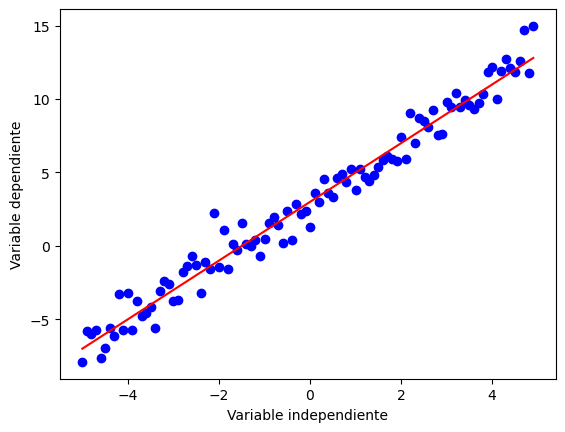

In [34]:
plt.plot(x,ydata,'bo')
plt.plot(x,y, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable independiente')
plt.show()

In [35]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(pol_grado1, x, ydata)

In [36]:
print("beta_0 = ",popt[0], "beta_1 = ", popt[1])

beta_0 =  3.0297435280647735 beta_1 =  2.0049058498799517


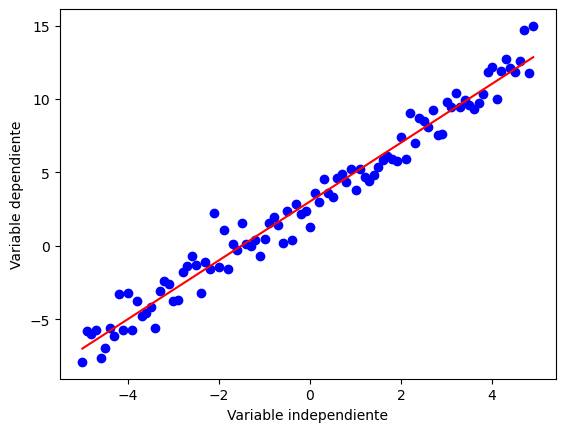

In [37]:
y_ajust = pol_grado1(x, popt[0], popt[1])
plt.plot(x,ydata,'bo')
plt.plot(x,y_ajust, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable independiente')
plt.show()

In [38]:
#Modelo polinomial de tercer grado
def pol_grado3(x, Beta_0, Beta_1, Beta_2, Beta_3):
    y = Beta_0 + Beta_1 * x + Beta_2(x**2) + Beta_3(x**3)
    return y

In [39]:
x = np.arange(-5.0, 5.0, 0.1)
y = pol_grado3(x, 3, 1, 1, 1)
y_noise = 20 * np.random.normal(0, 1, size=x.size)
ydata = y + y_noise

TypeError: 'int' object is not callable

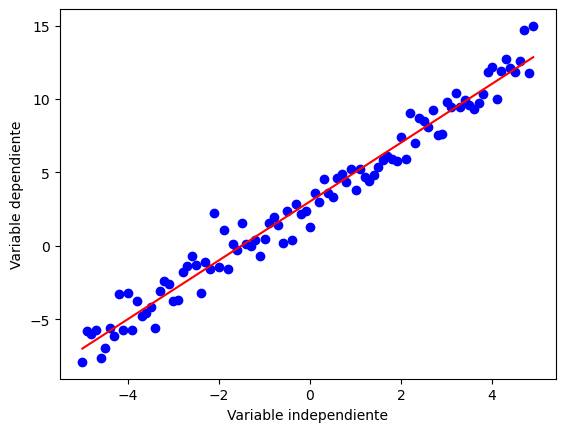

In [40]:
plt.plot(x,ydata,'bo')
plt.plot(x,y_ajust, 'r')
plt.ylabel('Variable dependiente')
plt.xlabel('Variable independiente')
plt.show()

In [41]:
msk = np.random.rand(len(df)) <= 0.80
msk

array([ True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True, False,  True,  True,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True, False, False,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True, False,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True, False,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,

In [42]:
train_x = x[msk]
test_x = x[~msk]
train_y = ydata[msk]
test_y = y[~msk]

IndexError: boolean index did not match indexed array along axis 0; size of axis is 100 but size of corresponding boolean axis is 945

In [43]:
popt.pcov = curve_fit(pol_grado3, train_x, train_y)

TypeError: 'numpy.float64' object is not callable

In [45]:
print("Beta_0 = ",popt[0], "Beta_1 = ", popt[1], "Beta_2 = ", popt[2], "Beta_3 = ", popt[3])

IndexError: index 2 is out of bounds for axis 0 with size 2

In [46]:
#Prediccion
y_hat = pol_grado3(test_x, *popt)

TypeError: pol_grado3() missing 2 required positional arguments: 'Beta_2' and 'Beta_3'

In [48]:
#EVALUACIÓN DE LOS ERRORES
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(y_hat, test_y))

ValueError: operands could not be broadcast together with shapes (190,1) (755,1) 

ValueError: x and y must have same first dimension, but have shapes (755, 1) and (190, 1)

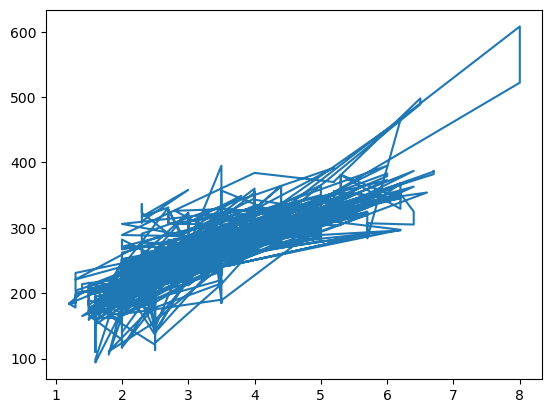

In [49]:
plt.plot(test_x, test_y)
plt.plot(test_x, y_hat)
plt.ylabel("Variable dependiente")
plt.xlabel("Variable independiente")
plt.show()

C:\Users\SURFACE\AppData\Local\Temp\ipykernel_19340\2743595204.py:6: RuntimeWarning: invalid value encountered in log
  Y = 2 + 6*np.log(X)


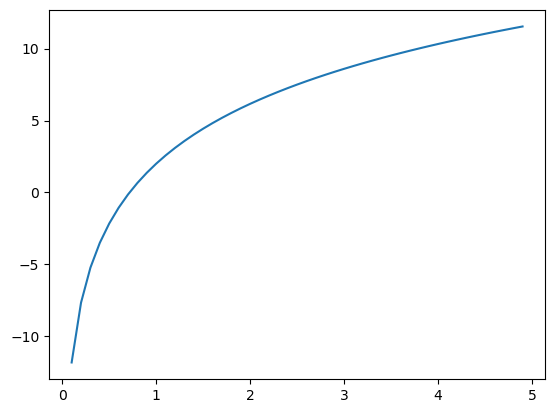

In [50]:
#Modelo exponencial
#Y =  a + b exp(x)

#Modelo logaritmico
X= np.arange(-5.0, 5.0, 0.1)
Y = 2 + 6*np.log(X)
plt.plot(X,Y)


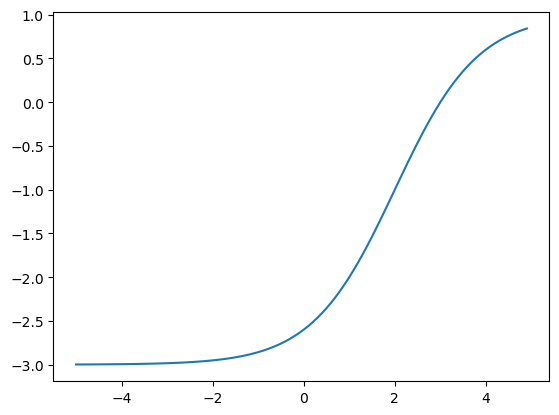

In [51]:
#Modelo Sigmoidal o Logistico
# Y = a + (b / (1 + c ** (x -d)))
X= np.arange(-5.0, 5.0, 0.1)
Y = 1-4/(1 + np.power(3, X-2))
plt.plot(X,Y)